# ISL Hand Sign Keypoint Classifier
This notebook trains a neural network to classify Indian Sign Language (ISL) hand signs (A-Z) using MediaPipe hand landmarks.

In [1]:
import csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

## 1. File Paths

In [2]:
#dataset        = 'model/keypoint_classifier/keypoint.csv'
dataset = "model/keypoint_classifier/keypoint.csv" # For both hands
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

## 2. Class Count

**KEY CHANGE:** Set this to the number of signs you have collected.

- For A-Z (26 letters, single-hand only): `NUM_CLASSES = 26`
- If you also have two-hand signs mixed in: keep the same count but make sure your CSV has the right feature length (see note below).

> **IMPORTANT — Input size note:**
> - Single-hand signs → 21 landmarks × 2 coords = **42 features** per row in the CSV
> - Two-hand signs → 42 landmarks × 2 coords = **84 features** per row in the CSV
>
> You must train **two separate models** if you mix single-hand and two-hand signs, OR pad
> single-hand rows with zeros to always have 84 features and use one model.
> The cell below uses `NUM_FEATURES` so you only have to change it in one place.

In [3]:
NUM_CLASSES = 26         # A-Z = 26. Change if you add more signs later.

# Always use 84 features regardless of one or two hands.
# Single-hand signs (like C) → 42 real features + 42 zeros (padding)
# Two-hand signs (like A)    → 42 features (left) + 42 features (right)
NUM_FEATURES = 42 * 2   # = 84

## 3. Load Training Data

In [4]:
# Column 0 = class label, columns 1..NUM_FEATURES = landmark coordinates
X_dataset = np.loadtxt(
    dataset,
    delimiter=',',
    dtype='float32',
    usecols=list(range(1, NUM_FEATURES + 1))
)

y_dataset = np.loadtxt(
    dataset,
    delimiter=',',
    dtype='int32',
    usecols=(0)
)

print(f'Dataset shape: X={X_dataset.shape}, y={y_dataset.shape}')
print(f'Classes found: {sorted(set(y_dataset.tolist()))}')

Dataset shape: X=(2600, 84), y=(2600,)
Classes found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


In [5]:
# Split: 75% training, 25% validation
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset,
    train_size=0.75,
    random_state=RANDOM_SEED
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 1950 samples | Test: 650 samples


## 4. Build the Model

**KEY CHANGES from original:**
- `Input` layer now uses `NUM_FEATURES` (42 for single-hand, 84 for two-hand)
- Hidden layers are wider (128 → 64) to handle 26 classes instead of 3
- Output layer uses `NUM_CLASSES` (26) instead of hardcoded 3

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((NUM_FEATURES,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 84)                0         
                                                                 
 dense (Dense)               (None, 128)               10880     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 26)                1690      
                                                                 
Total params: 20826 (81.35 KB)
Trainable params: 20826 (

## 5. Callbacks

In [7]:
# Save best model checkpoint
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    verbose=1,
    save_weights_only=False
)

# Stop early if validation loss stops improving
es_callback = tf.keras.callbacks.EarlyStopping(
    patience=20,
    verbose=1,
    restore_best_weights=True   # <-- added: revert to best epoch on stop
)

## 6. Compile

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train

In [9]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 9/16 [===============>..............] - ETA: 0s - loss: 3.2564 - accuracy: 0.0616 
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5


f:\Projects\NeuroSign\backend\venv_train\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


16/16 [==============================] - 3s 57ms/step - loss: 3.2047 - accuracy: 0.0862 - val_loss: 2.9361 - val_accuracy: 0.3677
Epoch 2/1000
 8/16 [==============>...............] - ETA: 0s - loss: 2.9907 - accuracy: 0.1465
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
16/16 [==============================] - 0s 14ms/step - loss: 2.9300 - accuracy: 0.1626 - val_loss: 2.5995 - val_accuracy: 0.4923
Epoch 3/1000
 1/16 [>.............................] - ETA: 0s - loss: 2.7398 - accuracy: 0.2578
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
16/16 [==============================] - 0s 15ms/step - loss: 2.6134 - accuracy: 0.2667 - val_loss: 2.1762 - val_accuracy: 0.5538
Epoch 4/1000
15/16 [===========================>..] - ETA: 0s - loss: 2.2699 - accuracy: 0.3276
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
16/16 [==============================] - 0s 27ms/step - loss: 2.2698 - accuracy: 0.3262 - val_

## 8. Evaluate

In [10]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)
print(f'Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

6/6 [==============================] - 0s 2ms/step - loss: 0.1022 - accuracy: 0.9738
Validation loss: 0.1022 | Validation accuracy: 0.9738


## 9. Reload Saved Model & Quick Inference Test

In [11]:
# Load the best saved model
model = tf.keras.models.load_model(model_save_path)

# Run inference on one test sample
predict_result = model.predict(np.array([X_test[0]]))
print('Class probabilities:', np.squeeze(predict_result))
print('Predicted class index:', np.argmax(np.squeeze(predict_result)))
print('True class index:     ', y_test[0])

1/1 [==============================] - 0s 82ms/step
Class probabilities: [1.2546286e-09 7.3944757e-12 6.0027985e-12 7.3637019e-14 3.8441408e-06
 2.4434250e-09 1.2888069e-11 2.1605017e-07 1.8086002e-06 1.0274928e-06
 6.3252822e-14 1.9859067e-13 9.8601043e-01 1.3803175e-02 1.3488155e-10
 7.1890936e-13 3.6384917e-09 7.8086759e-07 9.8960735e-12 3.7140355e-09
 9.4047391e-12 2.3538419e-13 1.5528867e-07 1.7245493e-10 1.2277392e-12
 1.7860079e-04]
Predicted class index: 12
True class index:      12


## 10. Confusion Matrix & Classification Report

21/21 [==============================] - 0s 2ms/step


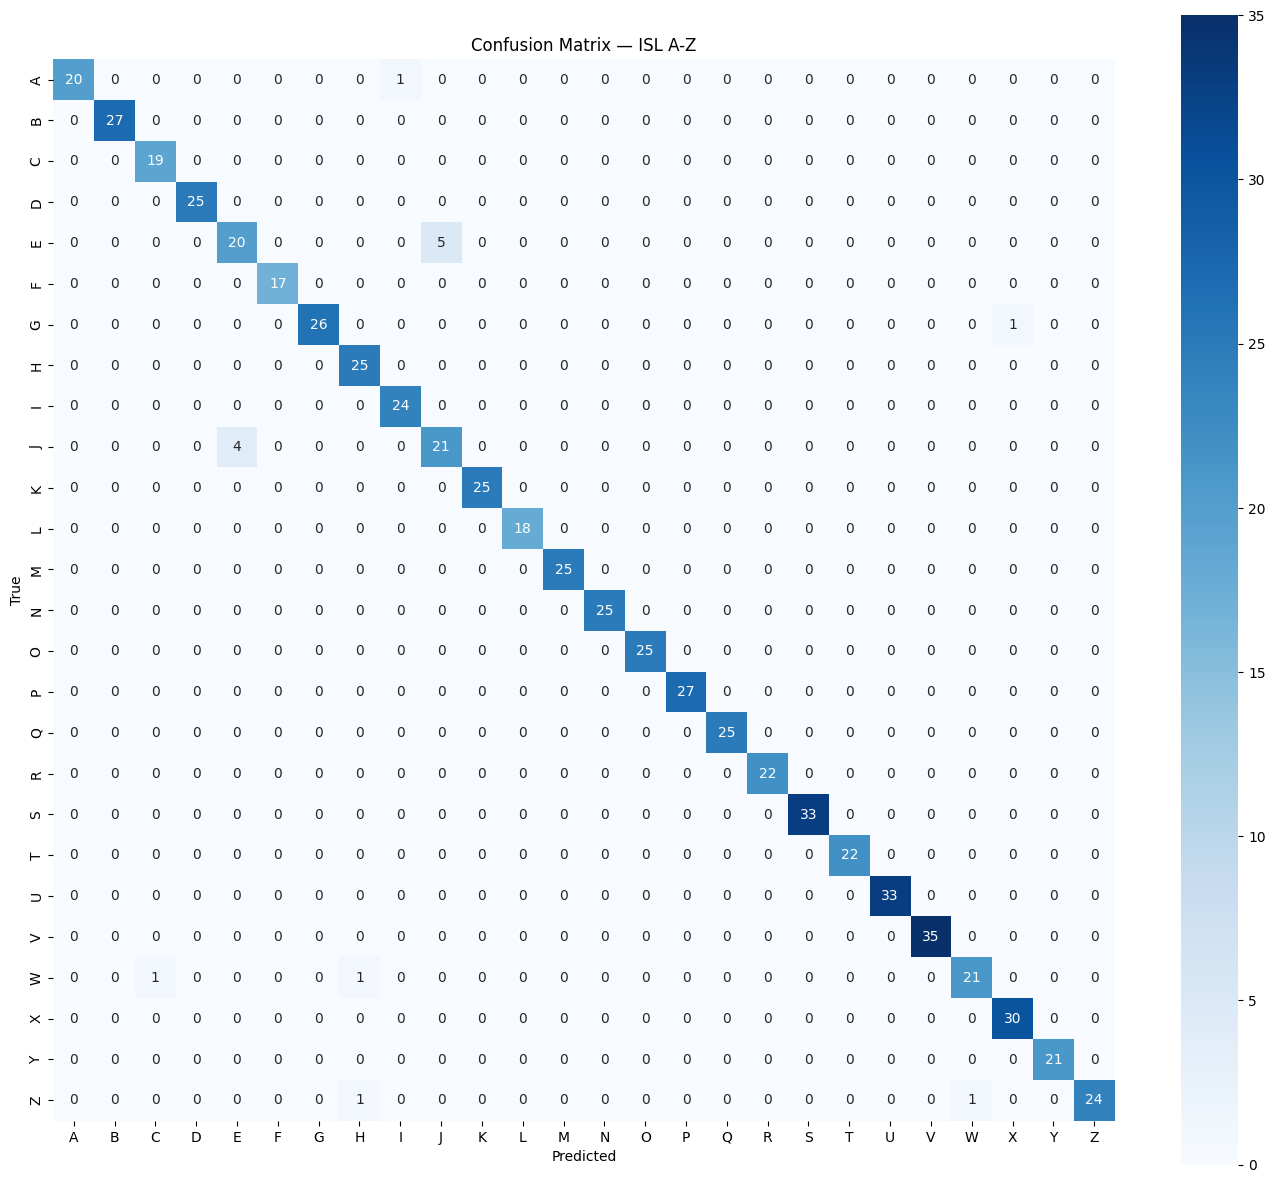

Classification Report
              precision    recall  f1-score   support

           A       1.00      0.95      0.98        21
           B       1.00      1.00      1.00        27
           C       0.95      1.00      0.97        19
           D       1.00      1.00      1.00        25
           E       0.83      0.80      0.82        25
           F       1.00      1.00      1.00        17
           G       1.00      0.96      0.98        27
           H       0.93      1.00      0.96        25
           I       0.96      1.00      0.98        24
           J       0.81      0.84      0.82        25
           K       1.00      1.00      1.00        25
           L       1.00      1.00      1.00        18
           M       1.00      1.00      1.00        25
           N       1.00      1.00      1.00        25
           O       1.00      1.00      1.00        25
           P       1.00      1.00      1.00        27
           Q       1.00      1.00      1.00        25
     

In [12]:
import string
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Map class indices 0-25 to letters A-Z for readable labels
ALPHABET = list(string.ascii_uppercase)  # ['A', 'B', ..., 'Z']

def print_confusion_matrix(y_true, y_pred, class_names, report=True):
    labels = sorted(list(set(y_true)))
    label_names = [class_names[i] for i in labels]

    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    df_cmx = pd.DataFrame(cmx_data, index=label_names, columns=label_names)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(df_cmx, annot=True, fmt='g', square=True, cmap='Blues')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — ISL A-Z')
    plt.tight_layout()
    plt.show()

    if report:
        print('Classification Report')
        print(classification_report(y_true, y_pred, target_names=label_names))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred, class_names=ALPHABET)

## 11. Convert to TensorFlow Lite (for use in app.py)

In [13]:
# Save inference-only model (no optimizer state)
model.save(model_save_path, include_optimizer=False)

f:\Projects\NeuroSign\backend\venv_train\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# Convert to quantized TFLite model (smaller & faster on CPU/edge devices)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)
print(f'TFLite model saved to: {tflite_save_path}')

INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmpmxau8n7l\assets


INFO:tensorflow:Assets written to: C:\Users\admin\AppData\Local\Temp\tmpmxau8n7l\assets


TFLite model saved to: model/keypoint_classifier/keypoint_classifier.tflite


## 12. TFLite Inference Test

In [15]:
# Load TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

# Get input/output tensor info
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input shape expected by TFLite model:', input_details[0]['shape'])
# Should print: [1, 42] for single-hand or [1, 84] for two-hand

Input shape expected by TFLite model: [ 1 84]


In [16]:
%%time
# Run TFLite inference on one test sample
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

print('TFLite class probabilities:', np.squeeze(tflite_results))
print('TFLite predicted class:    ', np.argmax(np.squeeze(tflite_results)))
print('Keras  predicted class:    ', np.argmax(model.predict(np.array([X_test[0]]))))
print('True class:                ', y_test[0])

TFLite class probabilities: [1.15801124e-09 7.32859520e-12 4.95081883e-12 6.63063354e-14
 3.68814722e-06 2.47333043e-09 1.16425975e-11 1.89108562e-07
 1.60331354e-06 9.25877771e-07 5.37188431e-14 1.51072595e-13
 9.87466991e-01 1.23560205e-02 1.12731269e-10 6.28123476e-13
 3.19764548e-09 7.22230538e-07 8.80964138e-12 3.49428086e-09
 7.54187164e-12 1.95799486e-13 1.39872100e-07 1.62248187e-10
 1.07651312e-12 1.69754538e-04]
TFLite predicted class:     12
1/1 [==============================] - 0s 24ms/step
Keras  predicted class:     12
True class:                 12
CPU times: total: 93.8 ms
Wall time: 98.2 ms
